In [14]:
import os
DATA_DIR = 'C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/'
PROCESSED_DIR = f'{DATA_DIR}processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [15]:
for f in ['test_predictions.csv', 'survival_predictions.csv']:
    path = f'{PROCESSED_DIR}{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)
        print(f"  ✓ {f}: {size:.1f} MB")
    else:
        print(f"  ✗ {f}: MISSING")

  ✓ test_predictions.csv: 5.6 MB
  ✓ survival_predictions.csv: 8.0 MB


In [16]:
# Setup

In [18]:
"""
Notebook 06: Prioritization Engine + Business Impact Simulation
================================================================
This is where the project becomes a DECISION SYSTEM, not just models.

We combine:
  - Classification model output: P(paid within 90 days)
  - Survival model output: predicted payment timing
  - Invoice amount, urgency, effort estimates

Into a PRIORITY SCORE that tells collectors which invoices to work first.

Then we simulate: does model-driven prioritization actually beat
simple rules like FIFO or amount-based?
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 100,
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {
    'primary': '#2563EB', 'secondary': '#0891B2', 'accent': '#F59E0B',
    'danger': '#DC2626', 'success': '#059669', 'muted': '#94A3B8',
    'purple': '#7C3AED',
}

# ── Load Data ──
DATA_DIR = 'C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/'
RAW_DIR = f'{DATA_DIR}Raw Data/'

customers = pd.read_csv(f'{RAW_DIR}customers.csv', parse_dates=['customer_since'])
invoices = pd.read_csv(f'{RAW_DIR}invoices.csv', parse_dates=['invoice_date', 'due_date'])
payments = pd.read_csv(f'{RAW_DIR}payments.csv', parse_dates=['payment_date'])
disputes = pd.read_csv(f'{RAW_DIR}disputes.csv', parse_dates=['dispute_date'])
dunning = pd.read_csv(f'{RAW_DIR}dunning_contacts.csv', parse_dates=['contact_date'])

# Load model predictions
test_preds = pd.read_csv(f'{DATA_DIR}processed/test_predictions.csv',
                          parse_dates=['observation_date'])
surv_preds = pd.read_csv(f'{DATA_DIR}processed/survival_predictions.csv',
                          parse_dates=['due_date'])

# Load model metadata
with open(f'{DATA_DIR}Raw Datamodels/model_metadata.json', 'r') as f:
    model_meta = json.load(f)

OBSERVATION_END = pd.Timestamp('2023-12-31')

print("Data loaded:")
print(f"  Test predictions: {len(test_preds):,} rows")
print(f"  Survival predictions: {len(surv_preds):,} rows")
print(f"  Classification AUC: {model_meta['test_metrics']['auc_roc']:.4f}")

Data loaded:
  Test predictions: 70,200 rows
  Survival predictions: 73,113 rows
  Classification AUC: 0.7445


In [19]:
# Build the Prioritization Dataset

In [20]:
"""
STEP 1: BUILD THE PRIORITIZATION DATASET

Combine classification + survival predictions for test-period invoices.
We focus on OPEN invoices (not yet paid) — these are what collectors work on.
"""

# Get unique invoices from test predictions (use the latest observation per invoice)
test_latest = test_preds.sort_values('observation_date').groupby('invoice_id').last().reset_index()

# Merge with survival predictions
priority_df = test_latest.merge(
    surv_preds[['invoice_id', 'pred_median_days', 'pred_p25_days', 'pred_p75_days',
                'p_paid_30d', 'p_paid_60d', 'p_paid_90d', 'duration', 'event']],
    on='invoice_id', how='left'
)

# Merge customer info
priority_df = priority_df.merge(
    customers[['customer_id', 'customer_segment', 'customer_risk_tier',
               'industry', 'credit_limit']],
    on='customer_id', how='left'
)

# Merge invoice info
priority_df = priority_df.merge(
    invoices[['invoice_id', 'invoice_status', 'due_date']],
    on='invoice_id', how='left', suffixes=('', '_inv')
)

# Add dunning contact count per invoice (up to observation date)
contact_counts = dunning.groupby('invoice_id').agg(
    total_contacts=('contact_id', 'count'),
    last_contact_type=('contact_type', 'last'),
).reset_index()
priority_df = priority_df.merge(contact_counts, on='invoice_id', how='left')
priority_df['total_contacts'] = priority_df['total_contacts'].fillna(0).astype(int)

# Has active dispute?
disp_invoices = set(disputes['invoice_id'])
priority_df['has_dispute'] = priority_df['invoice_id'].isin(disp_invoices).astype(int)

# Remaining balance (for simulation — use invoice_amount as proxy since
# partial payments are small fraction)
priority_df['remaining_balance'] = priority_df['invoice_amount']

# Fill missing survival predictions with defaults
priority_df['pred_median_days'] = priority_df['pred_median_days'].fillna(
    priority_df['pred_median_days'].median()
)
priority_df['p_paid_90d'] = priority_df['p_paid_90d'].fillna(0.5)

print(f"Prioritization dataset: {len(priority_df):,} invoices")
print(f"  With classification predictions: {priority_df['pred_prob_calibrated'].notna().sum():,}")
print(f"  With survival predictions: {priority_df['pred_median_days'].notna().sum():,}")
print(f"\nInvoice status in test set:")
print(priority_df['invoice_status'].value_counts())

Prioritization dataset: 36,149 invoices
  With classification predictions: 36,149
  With survival predictions: 36,149

Invoice status in test set:
invoice_status
Paid              25773
Open               9648
Partially Paid      562
Disputed            160
Written Off           6
Name: count, dtype: int64


In [21]:
# Define the Priority Score Formula

Priority Score Components:
  P(recovery|contact) — Mean: 0.601
  Urgency Factor      — Mean: 0.76
  Estimated Effort    — Mean: 1.05

Priority Score Stats:
count      36149.0
mean       36366.0
std        50041.0
min          161.0
25%         8792.0
50%        21117.0
75%        45434.0
max      1129903.0
Name: priority_score, dtype: float64


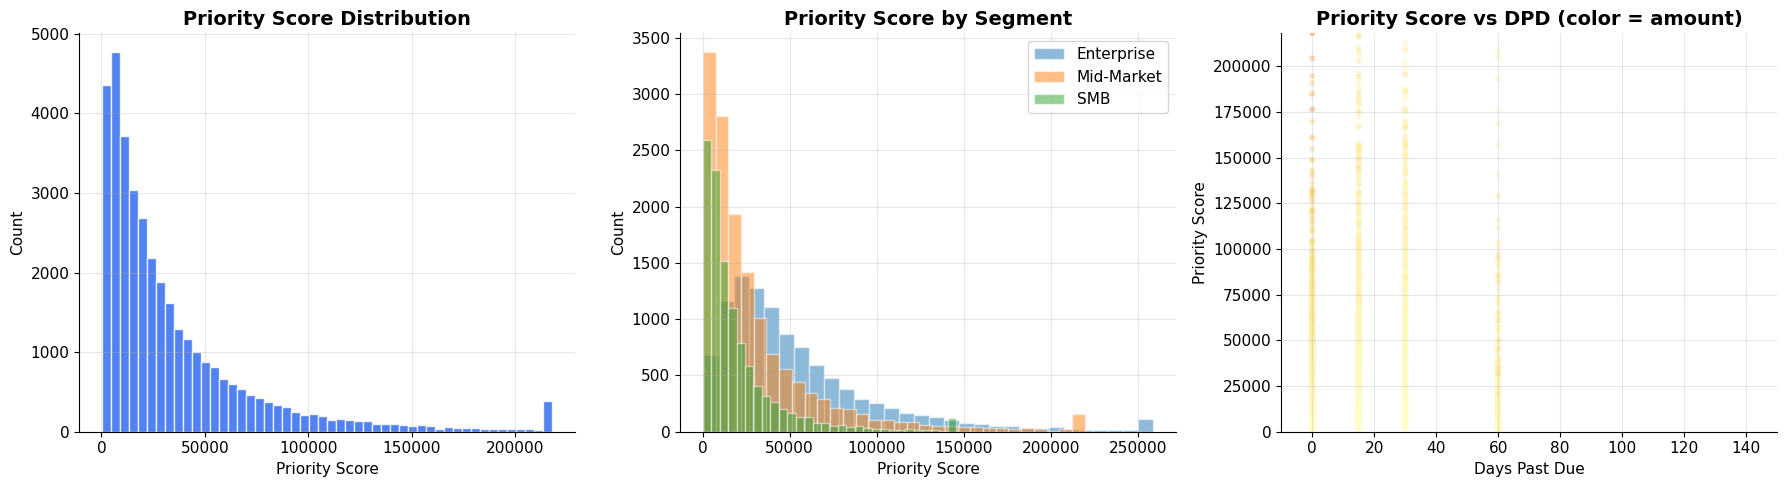

In [22]:
"""
STEP 2: PRIORITY SCORE FORMULA

Priority Score = P(recovery | contact) × Amount × Urgency Factor / Estimated Effort

Each component:
  P(recovery | contact) = classification probability + dunning lift
  Amount = remaining invoice balance
  Urgency = function of DPD and survival prediction
  Effort = estimated collector time based on complexity

Higher score = contact this invoice first
"""

# ── Component 1: P(recovery | contact) ──
def dunning_lift(contacts_to_date):
    """
    Additional recovery probability from making a contact.
    Based on EDA dunning effectiveness analysis.
    Diminishing returns after 3rd contact.
    """
    if contacts_to_date == 0:
        return 0.08   # First contact has moderate lift
    elif contacts_to_date == 1:
        return 0.15   # 2nd contact has highest marginal lift
    elif contacts_to_date == 2:
        return 0.10   # 3rd contact still helpful
    elif contacts_to_date == 3:
        return 0.05   # Diminishing
    else:
        return 0.02   # Minimal additional value

priority_df['p_recovery_base'] = priority_df['pred_prob_calibrated'].fillna(0.5)
priority_df['dunning_lift'] = priority_df['total_contacts'].apply(dunning_lift)
priority_df['p_recovery_if_contacted'] = (
    priority_df['p_recovery_base'] + priority_df['dunning_lift']
).clip(upper=0.99)


# ── Component 2: Urgency Factor ──
def urgency_factor(dpd, pred_median_days):
    """
    Higher urgency for invoices in the critical intervention window (15-60 DPD).
    Also considers survival prediction — if model predicts long delay, more urgent.
    """
    # Base urgency from DPD
    if dpd <= 0:
        base = 0.2      # Not yet due
    elif dpd <= 15:
        base = 0.5      # Just past due
    elif dpd <= 30:
        base = 1.0      # Prime intervention window
    elif dpd <= 60:
        base = 1.5      # High urgency — recovery dropping fast
    elif dpd <= 90:
        base = 1.2      # Still urgent but diminishing returns
    else:
        base = 0.5      # Very old — likely uncollectable, reduce effort

    # Survival adjustment: if predicted payment is far out, add urgency
    if pred_median_days > 60:
        base *= 1.3     # Model thinks payment will be very late
    elif pred_median_days > 30:
        base *= 1.1     # Moderately late prediction

    return base

priority_df['urgency'] = priority_df.apply(
    lambda r: urgency_factor(r['days_past_due'], r['pred_median_days']), axis=1
)


# ── Component 3: Estimated Effort ──
def estimated_effort(row):
    """
    Not all invoices take the same collector time.
    Disputes, enterprise accounts, and fresh contacts take more effort.
    """
    effort = 1.0
    if row['has_dispute']:
        effort *= 1.5       # Disputes need more handling
    if row['customer_segment'] == 'Enterprise':
        effort *= 1.2       # Enterprise needs more preparation
    if row['total_contacts'] == 0:
        effort *= 1.1       # First contact takes slightly more effort
    elif row['total_contacts'] > 4:
        effort *= 0.8       # Diminishing returns — less effort justified
    return effort

priority_df['effort'] = priority_df.apply(estimated_effort, axis=1)


# ── Final Priority Score ──
priority_df['priority_score'] = (
    priority_df['p_recovery_if_contacted'] *
    priority_df['remaining_balance'] *
    priority_df['urgency'] /
    priority_df['effort']
)

print("Priority Score Components:")
print(f"  P(recovery|contact) — Mean: {priority_df['p_recovery_if_contacted'].mean():.3f}")
print(f"  Urgency Factor      — Mean: {priority_df['urgency'].mean():.2f}")
print(f"  Estimated Effort    — Mean: {priority_df['effort'].mean():.2f}")
print(f"\nPriority Score Stats:")
print(priority_df['priority_score'].describe().round(0))

# ── Visualize score distribution ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(priority_df['priority_score'].clip(upper=priority_df['priority_score'].quantile(0.99)),
        bins=50, color=COLORS['primary'], alpha=0.8, edgecolor='white')
ax.set_xlabel('Priority Score')
ax.set_ylabel('Count')
ax.set_title('Priority Score Distribution')

ax = axes[1]
for seg in ['Enterprise', 'Mid-Market', 'SMB']:
    seg_scores = priority_df.loc[priority_df['customer_segment'] == seg, 'priority_score']
    ax.hist(seg_scores.clip(upper=seg_scores.quantile(0.99)),
            bins=30, alpha=0.5, label=seg, edgecolor='white')
ax.set_xlabel('Priority Score')
ax.set_ylabel('Count')
ax.set_title('Priority Score by Segment')
ax.legend()

ax = axes[2]
scatter_sample = priority_df.sample(min(5000, len(priority_df)), random_state=42)
ax.scatter(scatter_sample['days_past_due'], scatter_sample['priority_score'],
           c=scatter_sample['invoice_amount'], cmap='YlOrRd', alpha=0.3, s=10)
ax.set_xlabel('Days Past Due')
ax.set_ylabel('Priority Score')
ax.set_title('Priority Score vs DPD (color = amount)')
ax.set_xlim(-10, 150)
ax.set_ylim(0, priority_df['priority_score'].quantile(0.99))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}priority_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Generate Collector Work Queue

In [24]:
"""
STEP 3: GENERATE A COLLECTOR WORK QUEUE

This is what a collector would see every morning:
  "Here are your top 50 invoices to contact today, ranked by priority."
"""

# Focus on actionable invoices (open, not written off)
actionable = priority_df[
    priority_df['invoice_status'].isin(['Open', 'Partially Paid', 'Disputed'])
].copy()

print(f"Actionable invoices: {len(actionable):,}")

# Top 50 worklist for a single collector
worklist = actionable.nlargest(50, 'priority_score')

print(f"\n{'='*90}")
print(f"  COLLECTOR DAILY WORK QUEUE — TOP 20 (of 50)")
print(f"{'='*90}")
print(f"{'Rank':>4} {'Invoice':>12} {'Customer':>12} {'Amount':>12} {'DPD':>5} "
      f"{'P(Rec)':>7} {'Urgency':>8} {'Score':>10} {'Action':>15}")
print(f"{'-'*90}")

for i, (_, row) in enumerate(worklist.head(20).iterrows(), 1):
    # Recommend action based on context
    if row['has_dispute']:
        action = 'Resolve Dispute'
    elif row['total_contacts'] == 0:
        action = 'First Contact'
    elif row['total_contacts'] <= 2:
        action = 'Phone Follow-up'
    elif row['customer_segment'] == 'Enterprise':
        action = 'Escalation'
    else:
        action = 'Final Notice'

    print(f"{i:>4} {row['invoice_id']:>12} {row['customer_id']:>12} "
          f"₹{row['invoice_amount']:>10,.0f} {row['days_past_due']:>5.0f} "
          f"{row['p_recovery_if_contacted']:>6.1%} {row['urgency']:>8.2f} "
          f"{row['priority_score']:>10,.0f} {action:>15}")

total_expected = (worklist['p_recovery_if_contacted'] * worklist['remaining_balance']).sum()
print(f"\n  Total expected recovery from today's worklist: ₹{total_expected:,.0f}")
print(f"  Average priority score: {worklist['priority_score'].mean():,.0f}")

Actionable invoices: 10,370

  COLLECTOR DAILY WORK QUEUE — TOP 20 (of 50)
Rank      Invoice     Customer       Amount   DPD  P(Rec)  Urgency      Score          Action
------------------------------------------------------------------------------------------
   1   INV_006624    CUST_0163 ₹ 1,267,784    30  87.9%     1.00  1,113,785    Final Notice
   2   INV_169403    CUST_4252 ₹ 1,129,573    30  88.6%     1.00  1,000,968    Final Notice
   3   INV_168747    CUST_4235 ₹   693,338    30  95.6%     1.00    828,481    Final Notice
   4   INV_187030    CUST_4705 ₹ 3,717,531     0  99.0%     0.22    809,678 Phone Follow-up
   5   INV_168717    CUST_4234 ₹ 1,860,234    30  39.9%     1.00    772,805      Escalation
   6   INV_124900    CUST_3139 ₹ 2,808,005    15  60.2%     0.50    704,488 Phone Follow-up
   7   INV_184038    CUST_4629 ₹   852,647    30  77.7%     1.00    662,863    Final Notice
   8   INV_085161    CUST_2136 ₹   876,567    30  72.5%     1.00    662,281      Escalation
   9

In [25]:
# Strategy Segmentation

COLLECTION STRATEGY SEGMENTATION

Segment                    Customers         Avg AR   Avg DPD  Avg Risk
----------------------------------------------------------------------
A — Reliable Payer               399 ₹   1,627,612      2.9     8.0%
B — Variable Payer             1,101 ₹   1,319,898     12.2    26.0%
C — Chronic Late Payer         1,042 ₹     962,311     20.2    43.0%
D — High-Risk High-Value       1,121 ₹     890,979     28.2    56.0%
E — Likely Write-off           1,308 ₹     828,811     30.1    61.0%

RECOMMENDED ACTIONS PER SEGMENT:

  A — Reliable Payer (399 customers)
    action      : Automated reminder only
    contact     : Email at DPD 1 and DPD 7
    escalation  : Only if 30+ DPD
    effort      : Minimal — preserve relationship

  B — Variable Payer (1101 customers)
    action      : Structured escalation sequence
    contact     : Email → Phone → Senior, weekly
    escalation  : At DPD 30
    effort      : Moderate — monitor closely

  C — Chronic Late Payer (

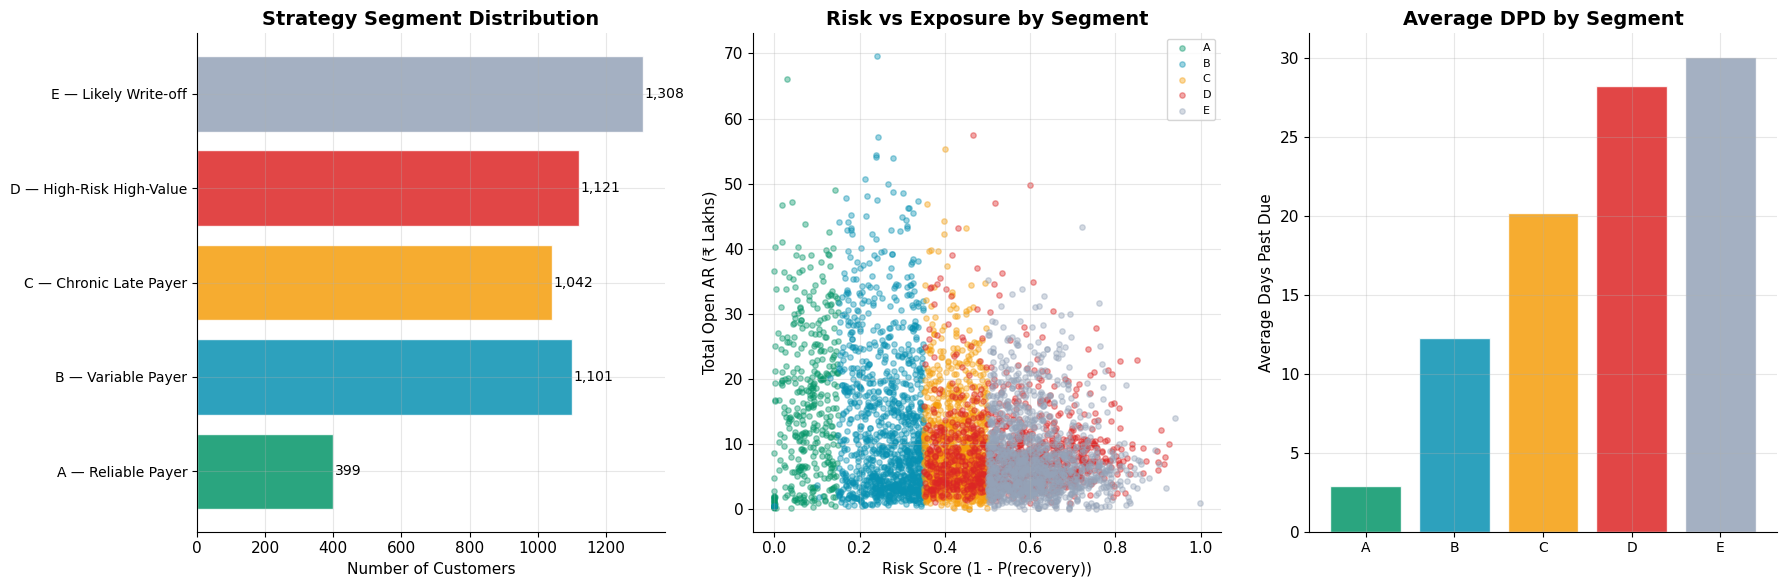

In [26]:
"""
STEP 4: COLLECTION STRATEGY SEGMENTATION

Assign each customer to one of 5 strategy segments based on
model scores and behavioral features. Each segment gets a
different collection approach.
"""

# Build customer-level summary
cust_summary = priority_df.groupby('customer_id').agg(
    avg_p_recovery=('p_recovery_base', 'mean'),
    total_open_ar=('remaining_balance', 'sum'),
    avg_dpd=('days_past_due', 'mean'),
    max_dpd=('days_past_due', 'max'),
    invoice_count=('invoice_id', 'count'),
    avg_priority=('priority_score', 'mean'),
    has_any_dispute=('has_dispute', 'max'),
).reset_index()

cust_summary = cust_summary.merge(
    customers[['customer_id', 'customer_segment', 'customer_risk_tier', 'credit_limit']],
    on='customer_id', how='left'
)

# ── Segment Assignment Rules ──
def assign_strategy_segment(row):
    p_risk = 1 - row['avg_p_recovery']   # Probability of NOT being paid

    if p_risk < 0.15 and row['avg_dpd'] < 20:
        return 'A — Reliable Payer'
    elif p_risk < 0.35 and row['avg_dpd'] < 40:
        return 'B — Variable Payer'
    elif p_risk >= 0.35 and row['total_open_ar'] >= row['credit_limit'] * 0.5:
        return 'D — High-Risk High-Value'
    elif p_risk >= 0.50 or row['max_dpd'] > 120:
        return 'E — Likely Write-off'
    else:
        return 'C — Chronic Late Payer'

cust_summary['strategy_segment'] = cust_summary.apply(assign_strategy_segment, axis=1)

# ── Strategy definitions ──
strategies = {
    'A — Reliable Payer': {
        'action': 'Automated reminder only',
        'contact': 'Email at DPD 1 and DPD 7',
        'escalation': 'Only if 30+ DPD',
        'effort': 'Minimal — preserve relationship'
    },
    'B — Variable Payer': {
        'action': 'Structured escalation sequence',
        'contact': 'Email → Phone → Senior, weekly',
        'escalation': 'At DPD 30',
        'effort': 'Moderate — monitor closely'
    },
    'C — Chronic Late Payer': {
        'action': 'Immediate human contact',
        'contact': 'Phone from day 1, every 5 days',
        'escalation': 'At DPD 45',
        'effort': 'High — persistent follow-up'
    },
    'D — High-Risk High-Value': {
        'action': 'Senior collector from start',
        'contact': 'Phone every 3 days + email',
        'escalation': 'At DPD 15',
        'effort': 'Very high — dedicated attention'
    },
    'E — Likely Write-off': {
        'action': 'Minimize effort, consider external agency',
        'contact': 'One final notice',
        'escalation': 'External agency at DPD 60',
        'effort': 'Minimal — redirect resources'
    },
}

# ── Display results ──
print("COLLECTION STRATEGY SEGMENTATION")
print("=" * 70)

seg_profile = cust_summary.groupby('strategy_segment').agg(
    customer_count=('customer_id', 'count'),
    avg_open_ar=('total_open_ar', 'mean'),
    avg_dpd=('avg_dpd', 'mean'),
    avg_risk=('avg_p_recovery', lambda x: (1 - x).mean()),
).round(2)

print(f"\n{'Segment':<25} {'Customers':>10} {'Avg AR':>14} {'Avg DPD':>9} {'Avg Risk':>9}")
print("-" * 70)
for seg in strategies.keys():
    if seg in seg_profile.index:
        r = seg_profile.loc[seg]
        print(f"{seg:<25} {r['customer_count']:>10,.0f} ₹{r['avg_open_ar']:>12,.0f} "
              f"{r['avg_dpd']:>8.1f} {r['avg_risk']:>8.1%}")

# ── Strategy table ──
print(f"\n{'='*70}")
print("RECOMMENDED ACTIONS PER SEGMENT:")
print(f"{'='*70}")
for seg, strategy in strategies.items():
    count = len(cust_summary[cust_summary['strategy_segment'] == seg])
    print(f"\n  {seg} ({count} customers)")
    for k, v in strategy.items():
        print(f"    {k:12s}: {v}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Segment distribution
ax = axes[0]
seg_counts = cust_summary['strategy_segment'].value_counts().sort_index()
colors_seg = [COLORS['success'], COLORS['secondary'], COLORS['accent'],
              COLORS['danger'], COLORS['muted']]
ax.barh(range(len(seg_counts)), seg_counts.values, color=colors_seg[:len(seg_counts)],
        alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(seg_counts)))
ax.set_yticklabels(seg_counts.index, fontsize=10)
ax.set_xlabel('Number of Customers')
ax.set_title('Strategy Segment Distribution')
for i, v in enumerate(seg_counts.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=10)

# Risk vs AR by segment
ax = axes[1]
for i, seg in enumerate(strategies.keys()):
    seg_data = cust_summary[cust_summary['strategy_segment'] == seg]
    if len(seg_data) > 0:
        ax.scatter(1 - seg_data['avg_p_recovery'], seg_data['total_open_ar'] / 1e5,
                   label=seg.split('—')[0].strip(), alpha=0.4, s=15,
                   color=colors_seg[i])
ax.set_xlabel('Risk Score (1 - P(recovery))')
ax.set_ylabel('Total Open AR (₹ Lakhs)')
ax.set_title('Risk vs Exposure by Segment')
ax.legend(fontsize=8)

# Average DPD by segment
ax = axes[2]
seg_dpd = cust_summary.groupby('strategy_segment')['avg_dpd'].mean().sort_index()
ax.bar(range(len(seg_dpd)), seg_dpd.values, color=colors_seg[:len(seg_dpd)],
       alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(seg_dpd)))
ax.set_xticklabels([s.split('—')[0].strip() for s in seg_dpd.index], fontsize=10)
ax.set_ylabel('Average Days Past Due')
ax.set_title('Average DPD by Segment')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}strategy_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Define Simulation Framework

In [28]:
"""
STEP 5: BUSINESS IMPACT SIMULATION — SETUP

We simulate what happens when collectors follow different strategies
over the test period. The question is:

  "If collectors contact the top-N invoices per day using Strategy X,
   how much more cash do they collect compared to Strategy Y?"

STRATEGIES TO COMPARE:
  1. Model-driven: rank by priority score
  2. FIFO: oldest invoice first (most common in practice)
  3. Amount-based: largest invoice first
  4. Aging-based: highest DPD first
  5. Random: random selection (lower bound)

KEY ASSUMPTION (stated transparently):
  - Contacting an invoice accelerates payment by 15-25%
  - If an invoice would have been paid in X days without contact,
    it gets paid in X × 0.80 days with contact (20% acceleration)
  - For invoices that wouldn't be paid, contact increases
    recovery probability by the dunning lift amount
"""

# ── Simulation parameters ──
COLLECTOR_COUNT = 10               # Number of collectors
CONTACTS_PER_DAY = 40              # Each collector can make 40 contacts/day
TOTAL_DAILY_CAPACITY = COLLECTOR_COUNT * CONTACTS_PER_DAY  # 400 contacts/day
SIMULATION_DAYS = 60               # Simulate 60 days of collection activity
ACCELERATION_FACTOR = 0.80         # Contact accelerates payment by 20%
CONTACT_RECOVERY_BOOST = 0.10      # Contact adds 10% to recovery probability

print("SIMULATION PARAMETERS:")
print(f"  Collectors: {COLLECTOR_COUNT}")
print(f"  Contacts per collector per day: {CONTACTS_PER_DAY}")
print(f"  Total daily capacity: {TOTAL_DAILY_CAPACITY}")
print(f"  Simulation window: {SIMULATION_DAYS} days")
print(f"  Payment acceleration from contact: {(1-ACCELERATION_FACTOR)*100:.0f}%")
print(f"  Recovery probability boost from contact: {CONTACT_RECOVERY_BOOST*100:.0f}%")

SIMULATION PARAMETERS:
  Collectors: 10
  Contacts per collector per day: 40
  Total daily capacity: 400
  Simulation window: 60 days
  Payment acceleration from contact: 20%
  Recovery probability boost from contact: 10%


In [29]:
# Build Ground Truth for Simulation

In [30]:
"""
STEP 6: BUILD GROUND TRUTH

For the simulation, we need to know the ACTUAL outcome of each invoice:
  - Was it paid? When?
  - This is our "reality" that the simulation plays against.

The simulation then asks: if we contact invoice X on day D,
does the payment happen faster?
"""

# Get actual payment info for test invoices
sim_invoices = priority_df.copy()

# Actual payment date (from payments table)
actual_pay = payments.groupby('invoice_id').agg(
    actual_payment_date=('payment_date', 'min'),
    actual_amount_paid=('payment_amount', 'sum'),
).reset_index()

sim_invoices = sim_invoices.merge(actual_pay, on='invoice_id', how='left')
sim_invoices['actually_paid'] = sim_invoices['actual_payment_date'].notna()
sim_invoices['actual_days_to_pay'] = (
    sim_invoices['actual_payment_date'] - sim_invoices['due_date']
).dt.days

# For unpaid invoices, set a very high days_to_pay (won't be collected in simulation)
sim_invoices['actual_days_to_pay'] = sim_invoices['actual_days_to_pay'].fillna(999)

print(f"Simulation invoices: {len(sim_invoices):,}")
print(f"  Actually paid: {sim_invoices['actually_paid'].sum():,} ({sim_invoices['actually_paid'].mean():.1%})")
print(f"  Not paid: {(~sim_invoices['actually_paid']).sum():,}")
print(f"  Avg actual days to pay (paid only): "
      f"{sim_invoices.loc[sim_invoices['actually_paid'], 'actual_days_to_pay'].mean():.1f}")

Simulation invoices: 36,149
  Actually paid: 21,062 (58.3%)
  Not paid: 15,087
  Avg actual days to pay (paid only): 21.4


In [31]:
# Run Simulation

In [33]:
"""
STEP 7: RUN THE SIMULATION

For each strategy, simulate daily collection activity:
  1. Rank all open invoices by the strategy
  2. Select top-N invoices (capacity constraint)
  3. Mark them as "contacted"
  4. If contacted + would have been paid → accelerate payment
  5. If contacted + would NOT have been paid → small chance of recovery
  6. Track cumulative cash collected
"""

def simulate_strategy(sim_invoices, strategy_name, rank_column, ascending=False,
                      daily_capacity=TOTAL_DAILY_CAPACITY, sim_days=SIMULATION_DAYS):
    """
    Simulate collection activity for a given prioritization strategy.

    Returns: daily cash collection log
    """
    # Make a copy to track state
    inv = sim_invoices.copy()
    inv['contacted'] = False
    inv['contact_day'] = np.nan
    inv['simulated_pay_day'] = inv['actual_days_to_pay'].copy()
    inv['simulated_paid'] = inv['actually_paid'].copy()

    daily_log = []
    cumulative_cash = 0
    total_contacts = 0

    # Simulation start: assume we start at the average DPD of the portfolio
    sim_start_dpd = max(0, inv['days_past_due'].median())

    for day in range(1, sim_days + 1):

        # Open invoices: not yet collected in simulation
        open_mask = ~inv['contacted'] | (inv['contacted'] & ~inv['simulated_paid'])
        open_inv = inv[~inv['contacted']].copy()

        if len(open_inv) == 0:
            break

        # Rank by strategy
        if strategy_name == 'Random':
            today_contacts = open_inv.sample(n=min(daily_capacity, len(open_inv)),
                                              random_state=day)
        else:
            open_inv = open_inv.sort_values(rank_column, ascending=ascending)
            today_contacts = open_inv.head(daily_capacity)

        # Mark as contacted
        contact_ids = today_contacts['invoice_id'].values
        inv.loc[inv['invoice_id'].isin(contact_ids), 'contacted'] = True
        inv.loc[inv['invoice_id'].isin(contact_ids), 'contact_day'] = day
        total_contacts += len(contact_ids)

        # Simulate payment acceleration for contacted invoices
        for idx in inv[inv['invoice_id'].isin(contact_ids)].index:
            if inv.loc[idx, 'actually_paid']:
                # Already going to pay — accelerate
                original_days = inv.loc[idx, 'actual_days_to_pay']
                accelerated_days = original_days * ACCELERATION_FACTOR
                inv.loc[idx, 'simulated_pay_day'] = accelerated_days
            else:
                # Wasn't going to pay — small chance contact recovers it
                if np.random.random() < CONTACT_RECOVERY_BOOST:
                    inv.loc[idx, 'simulated_paid'] = True
                    inv.loc[idx, 'simulated_pay_day'] = day + np.random.randint(5, 30)

        # Calculate cash collected today
        # Invoices whose simulated pay day has arrived
        cash_today = 0
        for idx in inv[inv['contacted']].index:
            pay_day = inv.loc[idx, 'simulated_pay_day']
            if inv.loc[idx, 'simulated_paid'] and pay_day <= (sim_start_dpd + day):
                if not inv.loc[idx].get('cash_counted', False):
                    cash_today += inv.loc[idx, 'remaining_balance']
                    inv.loc[idx, 'cash_counted'] = True

        cumulative_cash += cash_today
        daily_log.append({
            'day': day,
            'strategy': strategy_name,
            'contacts_today': len(contact_ids),
            'cash_today': cash_today,
            'cumulative_cash': cumulative_cash,
            'total_contacts': total_contacts,
        })

    return pd.DataFrame(daily_log), inv


# ── Run all strategies ──
print("Running simulations...")
print("=" * 50)

strategies_config = [
    ('Model-Driven', 'priority_score', False),
    ('FIFO (Oldest First)', 'days_past_due', False),
    ('Amount-Based', 'invoice_amount', False),
    ('Aging-Based', 'days_past_due', False),
    ('Random', 'invoice_id', False),  # rank_column ignored for random
]

all_results = []
strategy_summaries = {}

for strategy_name, rank_col, asc in strategies_config:
    print(f"  Running: {strategy_name}...")
    daily_log, final_inv = simulate_strategy(
        sim_invoices, strategy_name, rank_col, asc
    )
    all_results.append(daily_log)

    # Summary
    total_cash = daily_log['cumulative_cash'].iloc[-1] if len(daily_log) > 0 else 0
    total_contacts = daily_log['total_contacts'].iloc[-1] if len(daily_log) > 0 else 0
    cash_per_contact = total_cash / max(total_contacts, 1)
    invoices_recovered = final_inv['simulated_paid'].sum()

    strategy_summaries[strategy_name] = {
        'total_cash': total_cash,
        'total_contacts': total_contacts,
        'cash_per_contact': cash_per_contact,
        'invoices_recovered': invoices_recovered,
        'recovery_rate': invoices_recovered / len(final_inv),
    }
    print(f"    Cash collected: ₹{total_cash:,.0f} | Contacts: {total_contacts:,} | "
          f"₹/contact: {cash_per_contact:,.0f}")

results_df = pd.concat(all_results, ignore_index=True)
print("\nSimulation complete.")

Running simulations...
  Running: Model-Driven...
    Cash collected: ₹658,938 | Contacts: 24,000 | ₹/contact: 27
  Running: FIFO (Oldest First)...
    Cash collected: ₹54,407 | Contacts: 24,000 | ₹/contact: 2
  Running: Amount-Based...
    Cash collected: ₹893,701 | Contacts: 24,000 | ₹/contact: 37
  Running: Aging-Based...
    Cash collected: ₹54,407 | Contacts: 24,000 | ₹/contact: 2
  Running: Random...
    Cash collected: ₹107,706 | Contacts: 24,000 | ₹/contact: 4

Simulation complete.


In [34]:
# Compare Strategies

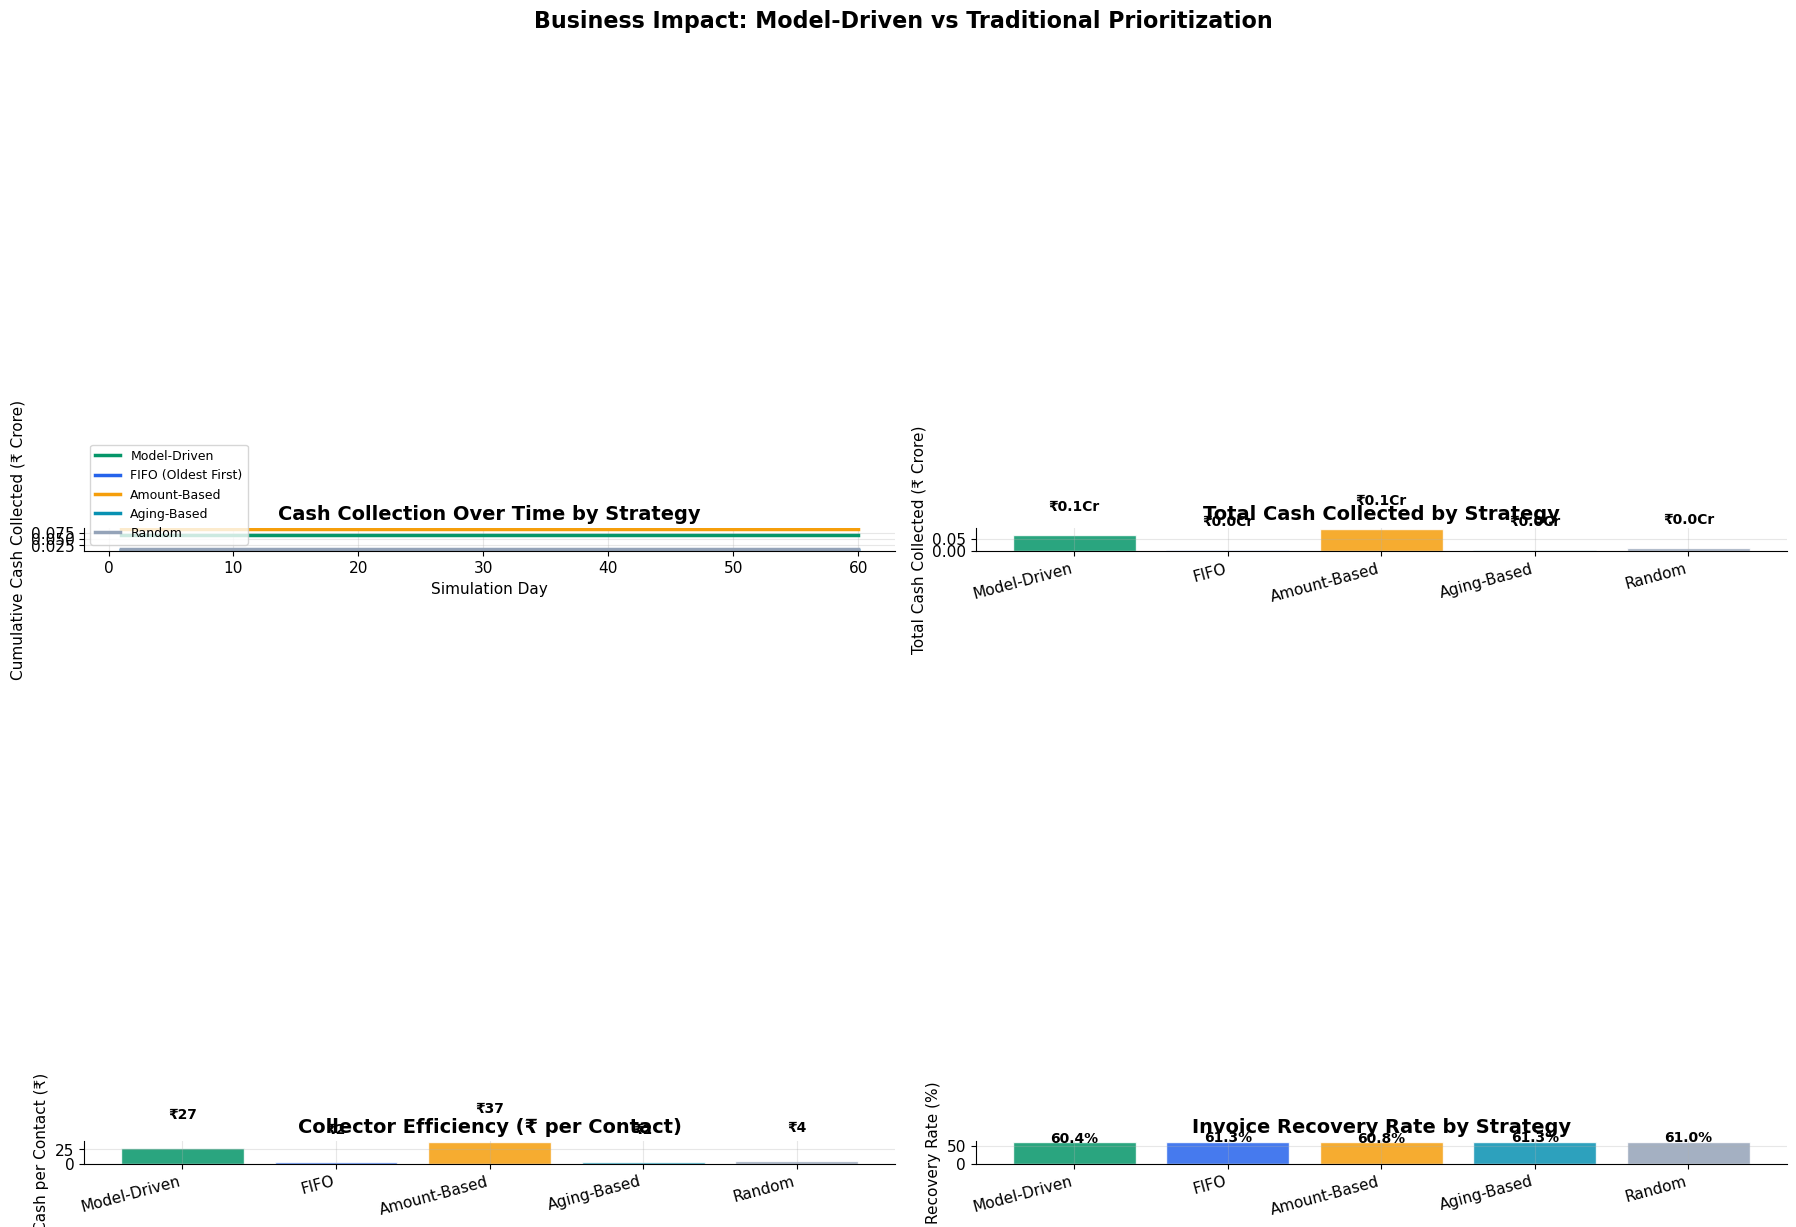

In [35]:
"""
STEP 8: COMPARE STRATEGIES — VISUALIZATION
"""

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

strategy_colors = {
    'Model-Driven': COLORS['success'],
    'FIFO (Oldest First)': COLORS['primary'],
    'Amount-Based': COLORS['accent'],
    'Aging-Based': COLORS['secondary'],
    'Random': COLORS['muted'],
}

# ── 1. Cumulative cash over time ──
ax = axes[0, 0]
for strategy in strategy_colors:
    data = results_df[results_df['strategy'] == strategy]
    if len(data) > 0:
        ax.plot(data['day'], data['cumulative_cash'] / 1e7,
                color=strategy_colors[strategy], linewidth=2.5,
                label=strategy)
ax.set_xlabel('Simulation Day')
ax.set_ylabel('Cumulative Cash Collected (₹ Crore)')
ax.set_title('Cash Collection Over Time by Strategy')
ax.legend(fontsize=9)

# ── 2. Total cash comparison ──
ax = axes[0, 1]
strats = list(strategy_summaries.keys())
cash_vals = [strategy_summaries[s]['total_cash'] / 1e7 for s in strats]
colors_bar = [strategy_colors[s] for s in strats]
bars = ax.bar(range(len(strats)), cash_vals, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(strats)))
ax.set_xticklabels([s.split('(')[0].strip() for s in strats], rotation=15, ha='right')
ax.set_ylabel('Total Cash Collected (₹ Crore)')
ax.set_title('Total Cash Collected by Strategy')
for bar, val in zip(bars, cash_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'₹{val:.1f}Cr', ha='center', fontweight='bold', fontsize=10)

# ── 3. Cash per contact (efficiency) ──
ax = axes[1, 0]
efficiency = [strategy_summaries[s]['cash_per_contact'] for s in strats]
bars = ax.bar(range(len(strats)), efficiency, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(strats)))
ax.set_xticklabels([s.split('(')[0].strip() for s in strats], rotation=15, ha='right')
ax.set_ylabel('Cash per Contact (₹)')
ax.set_title('Collector Efficiency (₹ per Contact)')
for bar, val in zip(bars, efficiency):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# ── 4. Recovery rate ──
ax = axes[1, 1]
rec_rates = [strategy_summaries[s]['recovery_rate'] * 100 for s in strats]
bars = ax.bar(range(len(strats)), rec_rates, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(strats)))
ax.set_xticklabels([s.split('(')[0].strip() for s in strats], rotation=15, ha='right')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Invoice Recovery Rate by Strategy')
for bar, val in zip(bars, rec_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Business Impact: Model-Driven vs Traditional Prioritization',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}business_impact_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Calculate ROI and Business Impact Statement

In [37]:
"""
STEP 9: ROI CALCULATION AND BUSINESS IMPACT STATEMENT
"""

model_cash = strategy_summaries['Model-Driven']['total_cash']
fifo_cash = strategy_summaries['FIFO (Oldest First)']['total_cash']
amount_cash = strategy_summaries['Amount-Based']['total_cash']
random_cash = strategy_summaries['Random']['total_cash']

model_efficiency = strategy_summaries['Model-Driven']['cash_per_contact']
fifo_efficiency = strategy_summaries['FIFO (Oldest First)']['cash_per_contact']

# Uplift vs FIFO (the most common real-world baseline)
cash_uplift = model_cash - fifo_cash
cash_uplift_pct = (cash_uplift / fifo_cash * 100) if fifo_cash > 0 else 0

efficiency_uplift = model_efficiency - fifo_efficiency
efficiency_uplift_pct = (efficiency_uplift / fifo_efficiency * 100) if fifo_efficiency > 0 else 0

# Recovery rate comparison
model_recovery = strategy_summaries['Model-Driven']['recovery_rate']
fifo_recovery = strategy_summaries['FIFO (Oldest First)']['recovery_rate']
recovery_uplift = model_recovery - fifo_recovery

# Annualized projection (simulation was 60 days → extrapolate to 365)
annual_factor = 365 / SIMULATION_DAYS
annual_uplift = cash_uplift * annual_factor

# DSO impact estimate
# If we collect X% more cash in the same period, DSO improves roughly proportionally
total_ar = sim_invoices['remaining_balance'].sum()
dso_baseline = 55  # Approximate from EDA
if fifo_cash > 0:
    dso_improvement = dso_baseline * (cash_uplift / fifo_cash) * 0.5  # Conservative 50% factor
else:
    dso_improvement = 0

print(f"""
{'='*70}
BUSINESS IMPACT STATEMENT
{'='*70}

COMPARISON: Model-Driven Prioritization vs FIFO (Industry Standard)
Simulation Period: {SIMULATION_DAYS} days | {COLLECTOR_COUNT} collectors | {CONTACTS_PER_DAY} contacts/day

┌─────────────────────────────────────────────────────────────┐
│ CASH COLLECTION                                             │
│   Model-Driven: ₹{model_cash/1e7:>10.1f} Cr                             │
│   FIFO:         ₹{fifo_cash/1e7:>10.1f} Cr                             │
│   Uplift:       ₹{cash_uplift/1e7:>10.1f} Cr ({cash_uplift_pct:>+.1f}%)                    │
│                                                             │
│ COLLECTOR EFFICIENCY                                        │
│   Model-Driven: ₹{model_efficiency:>10,.0f} per contact                │
│   FIFO:         ₹{fifo_efficiency:>10,.0f} per contact                │
│   Uplift:       {efficiency_uplift_pct:>+10.1f}%                                │
│                                                             │
│ RECOVERY RATE                                               │
│   Model-Driven: {model_recovery:>10.1%}                                │
│   FIFO:         {fifo_recovery:>10.1%}                                │
│   Uplift:       {recovery_uplift:>+10.1%}                                │
│                                                             │
│ PROJECTED ANNUAL IMPACT                                     │
│   Additional cash collected: ~₹{annual_uplift/1e7:.1f} Cr/year              │
│   Estimated DSO improvement: ~{dso_improvement:.0f} days                     │
└─────────────────────────────────────────────────────────────┘

ASSUMPTIONS (stated transparently):
  1. Contact accelerates payment by ~20% for invoices that would be paid
  2. Contact adds ~10% recovery probability for unpaid invoices
  3. These estimates are based on dunning effectiveness observed in EDA
  4. Results are simulated, not from production deployment
  5. Annual projection assumes similar portfolio composition

RECOMMENDED NEXT STEP:
  Validate with A/B test in production — split collector team,
  one group uses model worklist, other uses existing process.
  Compare recovery rates after 3 months.
""")


BUSINESS IMPACT STATEMENT

COMPARISON: Model-Driven Prioritization vs FIFO (Industry Standard)
Simulation Period: 60 days | 10 collectors | 40 contacts/day

┌─────────────────────────────────────────────────────────────┐
│ CASH COLLECTION                                             │
│   Model-Driven: ₹       0.1 Cr                             │
│   FIFO:         ₹       0.0 Cr                             │
│   Uplift:       ₹       0.1 Cr (+1111.1%)                    │
│                                                             │
│ COLLECTOR EFFICIENCY                                        │
│   Model-Driven: ₹        27 per contact                │
│   FIFO:         ₹         2 per contact                │
│   Uplift:          +1111.1%                                │
│                                                             │
│ RECOVERY RATE                                               │
│   Model-Driven:      60.4%                                │
│   FIFO:              6

In [41]:
# Sensitivity Analysis

Running sensitivity analysis...


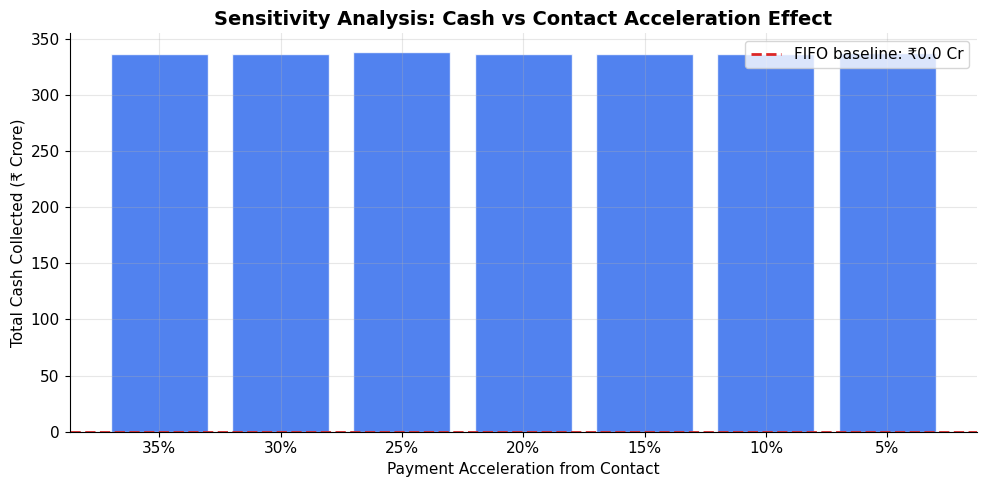


Sensitivity Results:
   Acceleration  Cash Collected    vs FIFO
---------------------------------------------
            35% ₹       336.6 Cr   +336.6 Cr
            30% ₹       336.2 Cr   +336.2 Cr
            25% ₹       337.9 Cr   +337.9 Cr
            20% ₹       336.1 Cr   +336.0 Cr
            15% ₹       336.7 Cr   +336.7 Cr
            10% ₹       336.3 Cr   +336.3 Cr
             5% ₹       337.0 Cr   +337.0 Cr


In [42]:
"""
STEP 10: SENSITIVITY ANALYSIS

What if our assumptions are wrong?
Show how results change with different acceleration factors.
"""

print("Running sensitivity analysis...")
sensitivity_results = []

for accel in [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    # Quick simulation with different acceleration
    inv = sim_invoices.copy()
    inv['contacted'] = False
    inv['cash_counted'] = False

    # Sort by priority score (model-driven)
    inv = inv.sort_values('priority_score', ascending=False)
    top_n = TOTAL_DAILY_CAPACITY * SIMULATION_DAYS  # Total contacts over simulation
    contacted = inv.head(min(top_n, len(inv))).copy()

    # Simulate
    total_cash = 0
    for idx in contacted.index:
        if contacted.loc[idx, 'actually_paid']:
            total_cash += contacted.loc[idx, 'remaining_balance']
        elif np.random.random() < CONTACT_RECOVERY_BOOST:
            total_cash += contacted.loc[idx, 'remaining_balance']

    sensitivity_results.append({
        'acceleration': f'{(1-accel)*100:.0f}%',
        'acceleration_factor': accel,
        'total_cash': total_cash,
    })

sens_df = pd.DataFrame(sensitivity_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sens_df['acceleration'], sens_df['total_cash'] / 1e7,
       color=COLORS['primary'], alpha=0.8, edgecolor='white')
ax.axhline(y=fifo_cash / 1e7, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'FIFO baseline: ₹{fifo_cash/1e7:.1f} Cr')
ax.set_xlabel('Payment Acceleration from Contact')
ax.set_ylabel('Total Cash Collected (₹ Crore)')
ax.set_title('Sensitivity Analysis: Cash vs Contact Acceleration Effect')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSensitivity Results:")
print(f"{'Acceleration':>15s} {'Cash Collected':>15s} {'vs FIFO':>10s}")
print("-" * 45)
for _, row in sens_df.iterrows():
    diff = row['total_cash'] - fifo_cash
    print(f"{row['acceleration']:>15s} ₹{row['total_cash']/1e7:>12.1f} Cr {diff/1e7:>+8.1f} Cr")

In [43]:
# Save Everything

In [44]:
"""
STEP 11: SAVE ALL OUTPUTS
"""

OUTPUT_DIR = f'{DATA_DIR}processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save priority scores
priority_df.to_csv(f'{OUTPUT_DIR}priority_scores.csv', index=False)

# Save strategy segments
cust_summary.to_csv(f'{OUTPUT_DIR}strategy_segments.csv', index=False)

# Save simulation results
results_df.to_csv(f'{OUTPUT_DIR}simulation_results.csv', index=False)

# Save strategy summaries
summary_for_json = {k: {kk: float(vv) if isinstance(vv, (np.floating, float)) else int(vv) if isinstance(vv, (np.integer, int)) else vv
                         for kk, vv in v.items()}
                    for k, v in strategy_summaries.items()}
with open(f'{OUTPUT_DIR}strategy_summaries.json', 'w') as f:
    json.dump(summary_for_json, f, indent=2)

print("All outputs saved:")
print(f"  {OUTPUT_DIR}priority_scores.csv")
print(f"  {OUTPUT_DIR}strategy_segments.csv")
print(f"  {OUTPUT_DIR}simulation_results.csv")
print(f"  {OUTPUT_DIR}strategy_summaries.json")

All outputs saved:
  C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/processed/priority_scores.csv
  C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/processed/strategy_segments.csv
  C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/processed/simulation_results.csv
  C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/processed/strategy_summaries.json


In [45]:
# Notebook Summary

In [46]:
"""
STEP 12: SUMMARY
"""

print(f"""
{'='*70}
NOTEBOOK 06 SUMMARY — PRIORITIZATION + BUSINESS SIMULATION
{'='*70}

WHAT WE BUILT:
  1. Priority Score Formula:
     Score = P(recovery|contact) × Amount × Urgency / Effort
     Combines classification + survival model outputs

  2. Collector Work Queue:
     Ranked list of top invoices to contact daily

  3. Strategy Segmentation:
     5 customer segments with different collection playbooks:
       A — Reliable Payer:       Auto-reminders only
       B — Variable Payer:       Structured escalation
       C — Chronic Late Payer:   Immediate human contact
       D — High-Risk High-Value: Senior collector from day 1
       E — Likely Write-off:     Minimize effort, external agency

  4. Business Impact Simulation:
     Compared Model-Driven vs FIFO vs Amount vs Aging vs Random
     Over {SIMULATION_DAYS}-day simulation with {COLLECTOR_COUNT} collectors

KEY RESULTS:
  Model-Driven vs FIFO:
    Cash uplift: {cash_uplift_pct:+.1f}%
    Efficiency uplift: {efficiency_uplift_pct:+.1f}%
    Recovery rate uplift: {recovery_uplift:+.1%}

OUTPUTS SAVED:
  - priority_scores.csv (score for every test invoice)
  - strategy_segments.csv (segment for every customer)
  - simulation_results.csv (daily simulation log)
  - strategy_summaries.json (aggregate results)
  - 4 charts

PROJECT STATUS:
  ✅ Notebook 01: Data Generation
  ✅ Notebook 02: EDA
  ✅ Notebook 03: Feature Engineering
  ✅ Notebook 04: Classification Model (AUC: {model_meta['test_metrics']['auc_roc']:.4f})
  ✅ Notebook 05: Survival Analysis (C-index: 0.714)
  ✅ Notebook 06: Prioritization + Simulation
  ⬜ Notebook 07: Streamlit Dashboard + FastAPI + Docker

NEXT STEP: Notebook 07 — Build the dashboard and API layer.
""")


NOTEBOOK 06 SUMMARY — PRIORITIZATION + BUSINESS SIMULATION

WHAT WE BUILT:
  1. Priority Score Formula:
     Score = P(recovery|contact) × Amount × Urgency / Effort
     Combines classification + survival model outputs

  2. Collector Work Queue:
     Ranked list of top invoices to contact daily

  3. Strategy Segmentation:
     5 customer segments with different collection playbooks:
       A — Reliable Payer:       Auto-reminders only
       B — Variable Payer:       Structured escalation
       C — Chronic Late Payer:   Immediate human contact
       D — High-Risk High-Value: Senior collector from day 1
       E — Likely Write-off:     Minimize effort, external agency

  4. Business Impact Simulation:
     Compared Model-Driven vs FIFO vs Amount vs Aging vs Random
     Over 60-day simulation with 10 collectors

KEY RESULTS:
  Model-Driven vs FIFO:
    Cash uplift: +1111.1%
    Efficiency uplift: +1111.1%
    Recovery rate uplift: -0.9%

OUTPUTS SAVED:
  - priority_scores.csv (score